Ранее мы выяснили, что пользователи, совершившие покупку, реже быстро покидают сайт и в целом демонстрируют более высокую вовлеченность во взаимодействие с сайтом.

Теперь проверим, есть ли связь между более активным взаимодействием пользователя с административными и информационными страницами и снижением метрик ухода и повышением вероятности покупки. Для этого рассмотрим признаки Administrative, Administrative_Duration, Informational, Informational_Duration - на корреляционной матрице мы могли заметить достаточно высокие коэффициенты корреляции у этих признаков с ExitRates, BounceRates, а также Revenue.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.pylabtools import figsize

In [2]:
df = pd.read_csv('online_shoppers_intention.csv')

In [3]:
buyers = df[df['Revenue']==True]
not_buyers = df[df['Revenue']==False]

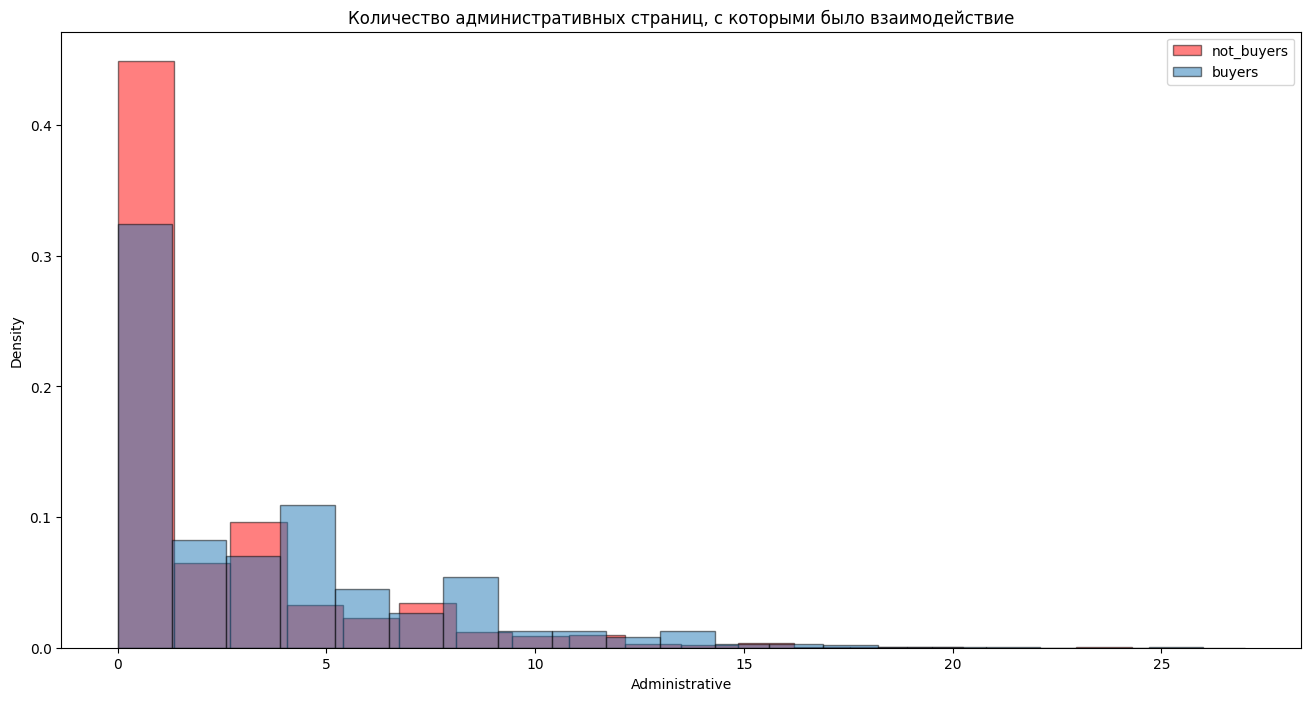

In [4]:
figsize(16, 8)

plt.hist(not_buyers['Administrative'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', color='red', label='not_buyers')
plt.hist(buyers['Administrative'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', label='buyers')

plt.xlabel('Administrative')
plt.ylabel('Density')
plt.title('Количество административных страниц, с которыми было взаимодействие')
plt.legend()

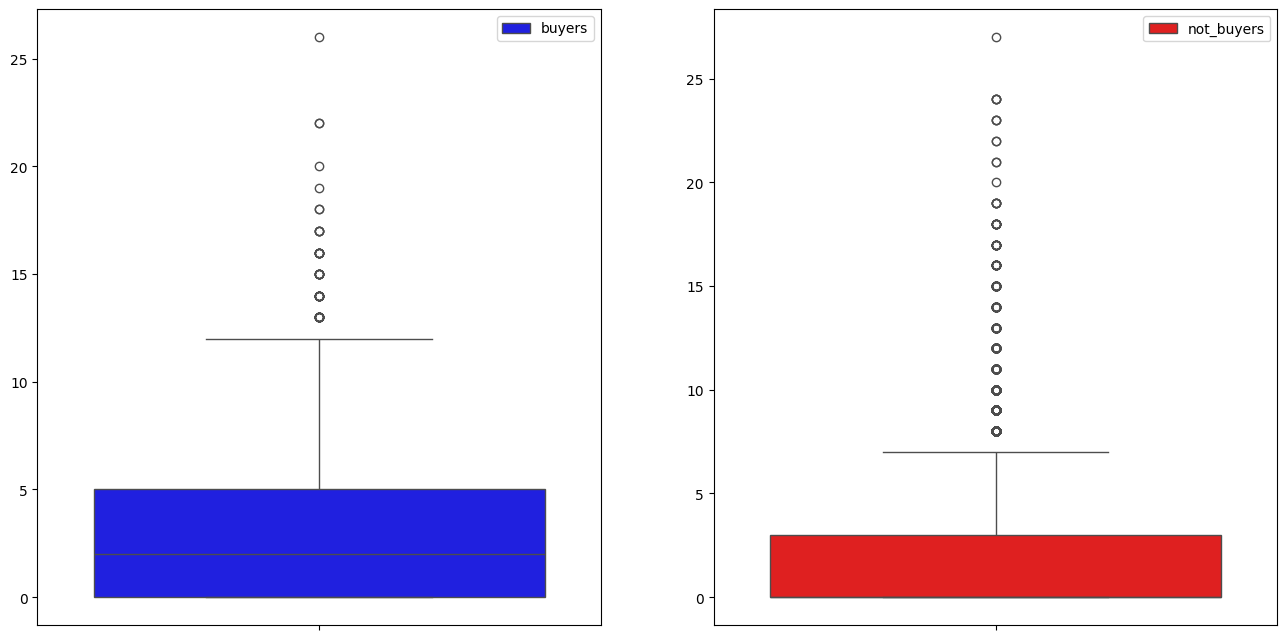

In [5]:
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
sns.boxplot(data=buyers['Administrative'].values, color = 'blue', label='buyers')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=not_buyers['Administrative'].values, color = 'red', label='not_buyers')
plt.legend()

Из представленных графиков мы видим, что покупатели взаимодействуют с большим количеством административных страниц в течение сессии, чем не покупатели: у не покупателей большинство значений сосредоточено около 0, а также медиана у покупателей выше.

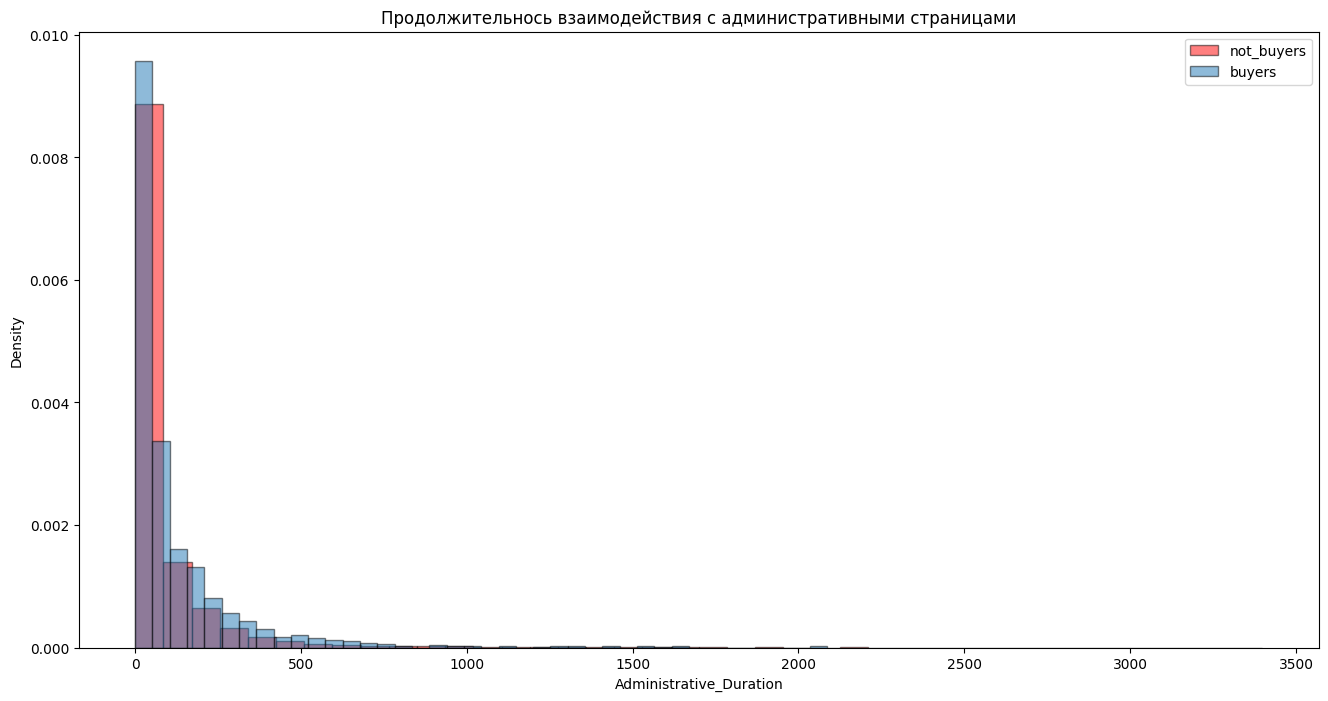

In [9]:
figsize(16, 8)

plt.hist(not_buyers['Administrative_Duration'], bins = 40, alpha=0.5, density=True, edgecolor = 'black', color='red', label='not_buyers')
plt.hist(buyers['Administrative_Duration'], bins = 40, alpha=0.5, density=True, edgecolor = 'black', label='buyers')

plt.xlabel('Administrative_Duration')
plt.ylabel('Density')
plt.title('Продолжительнось взаимодействия с административными страницами')
plt.legend()

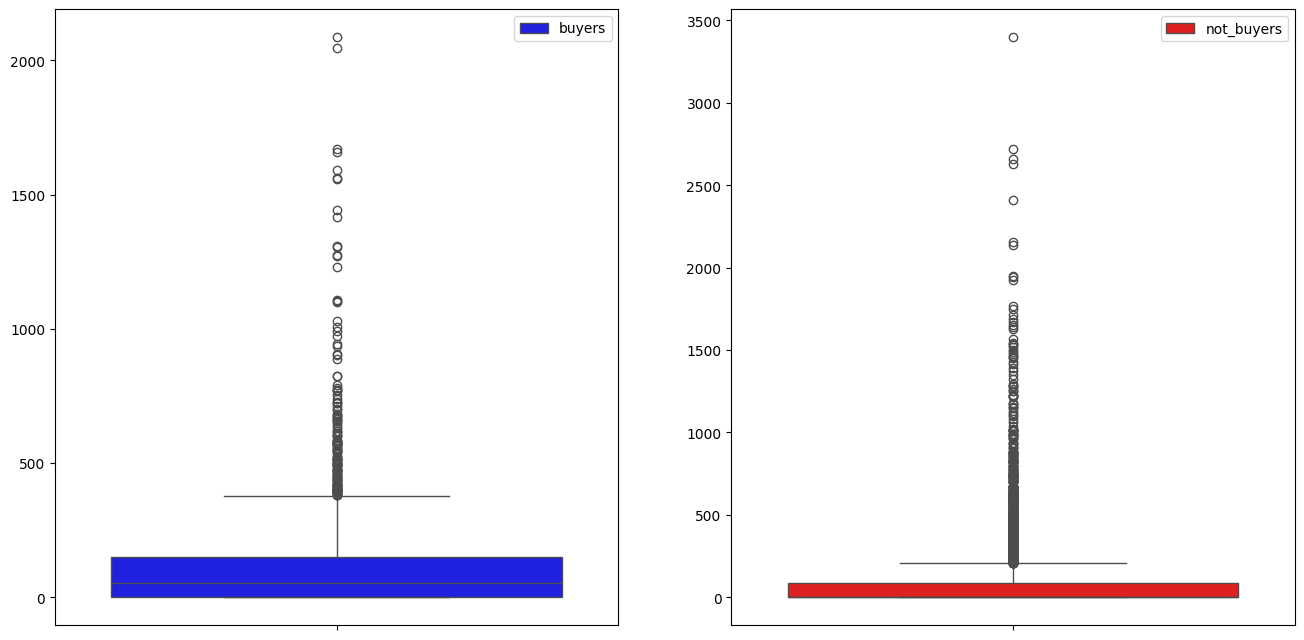

In [7]:
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
sns.boxplot(data=buyers['Administrative_Duration'].values, color = 'blue', label='buyers')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=not_buyers['Administrative_Duration'].values, color = 'red', label='not_buyers')
plt.legend()

По графикам видно, что большое количество значений времени взаимодействия близко к 0 или 0. Также у не покупателей есть большие выбросы значений, что может свидетельствовать о том, что пользователь долго пытался разобраться с функционалом сайта, устал и не стал делать заказ.

Интересно было бы посмотреть на это в разрезе типовов покупателей (первый раз они на сайте или нет). Возможно, у пользователей, которые не 1 раз на сайте, взаимодействие с административными страницами отнимает меньше времени.

Уточним атрибуты функции boxplot https://seaborn.pydata.org/generated/seaborn.boxplot.html

<Axes: xlabel='VisitorType', ylabel='Administrative_Duration'>

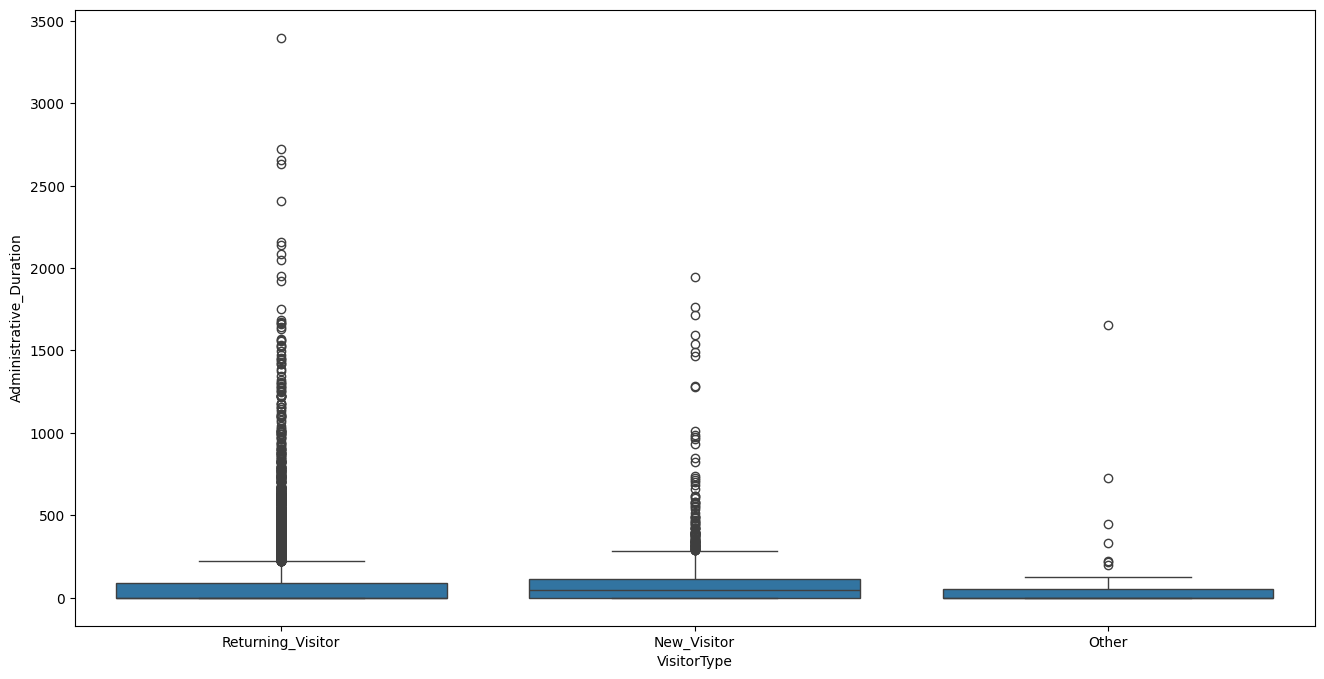

In [10]:
sns.boxplot(data=df, x='VisitorType', y='Administrative_Duration')

In [23]:
from scipy.stats import levene

levene(df[df['VisitorType']=='New_Visitor']['Administrative_Duration'], df[df['VisitorType']=='Returning_Visitor']['Administrative_Duration'])

LeveneResult(statistic=np.float64(0.15784975239804735), pvalue=np.float64(0.6911508884928254))

По графику видим, что в среднем новые пользователи дольше взимодействуют с административными страницами сайта, вероятно, изучают или регистрируются, при этом вернувшиеся пользователя иногда экстремально долго взаимодействует с данным типом страниц (о чем свидетелеьствуют выбросы). Причина у этого может быть разная, может, добавили в корзину/избранное и просматривают, а может, не могут разобраться в функционале и т.д.

<Axes: xlabel='VisitorType', ylabel='Administrative_Duration'>

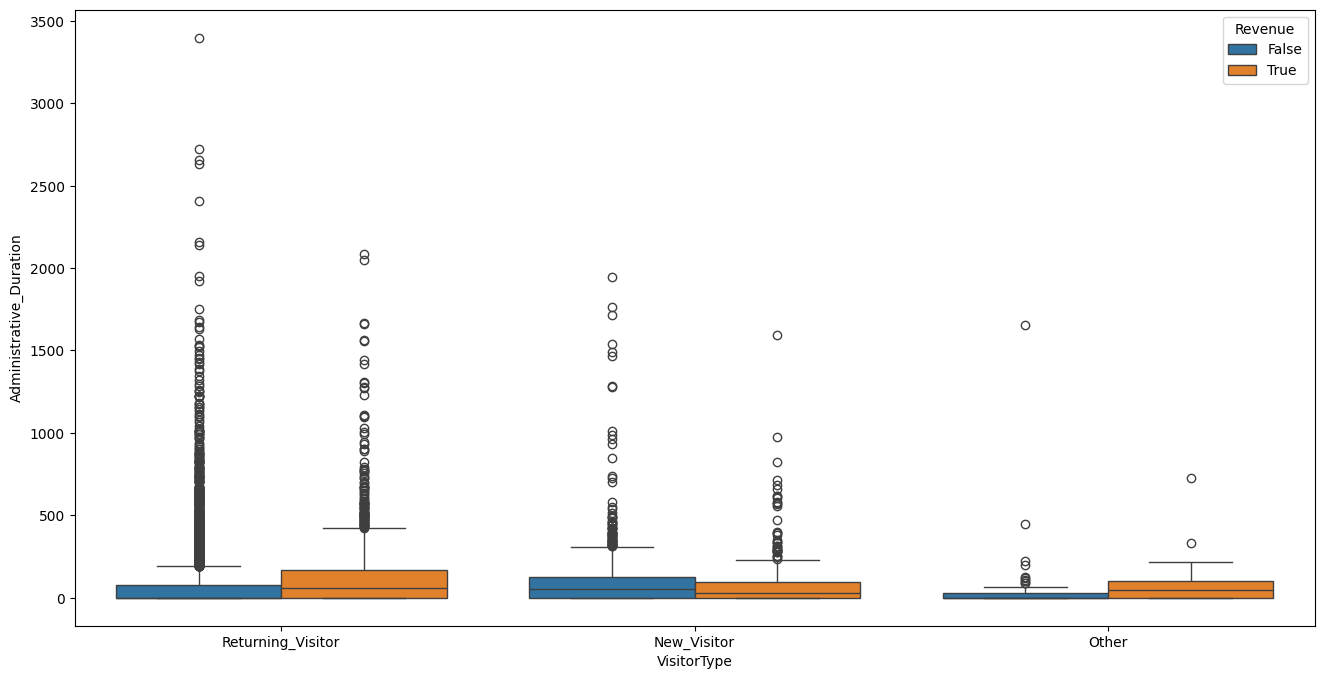

In [11]:
sns.boxplot(data=df, x='VisitorType', y='Administrative_Duration', hue='Revenue')

Итак, теперь мы видим, что вернувшиеся пользователи при дольшем взаимодействии с административными страницами чаще совершают покупку, вероятно, пользуются или для оформления заказа. При этом самые большие выбросы у группы вернувшихся пользователей, которые не сделали заказ. Это может говорить о нестандартном использовании страниц, например, просмотра корзины с добавленными продуктами, просмотра своего профиля и тд. 

У новых же посетителей долгое взаимодействие. административными страницами чаще приводит к отрицательному решению о покупке. Вероятно, непонятный функционал заставляет их уходить. Те же, кто быстро разобрался (их меньше), совершают покупку.

Other является группой посетителей, которых не удалось отнести ни к какому из типов по различным причинам, так что в этой части исследования для нас эта группа не несет ценности - не будем ее рассматривать.

Сформулируем следующие гипотезы:

H0: средние значения Administrative_Duration одинаковы для всех типов посетителей.

H1: хотя бы у одной группы среднее значение статистически значимо отличается.

Для проверки гипотез используем t-критерий Уэлча, потому что у нас 2 независимые выборки (вернувшиеся и новые посетители), Administrative_Duration - количественный признак, размеры групп отличаются, дисперсии тоже отличаются и в целом выборки неоднородные; также так как у нас очень много данных мы можем использовать t-тесты без нормальности данных. Источник: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

In [20]:
from scipy.stats import ttest_ind

ttest_ind(df[df['VisitorType']=='Returning_Visitor']['Administrative_Duration'], df[df['VisitorType']=='New_Visitor']['Administrative_Duration'], equal_var=False)

TtestResult(statistic=np.float64(-2.9642716178440245), pvalue=np.float64(0.0030637571329509504), df=np.float64(2409.6912449105725))

In [22]:
print("Среднее у новых пользователей:", df[df['VisitorType']=='New_Visitor']['Administrative_Duration'].mean())
print("Среднее у старых пользователей:", df[df['VisitorType']=='Returning_Visitor']['Administrative_Duration'].mean())

Среднее у новых пользователей: 91.9113146158955
Среднее у старых пользователей: 79.18363908545683


Видим, что p-value < 0.05, значит, отвергаем Н0. Следовательно, среднее время проведенное на административных страницах различается статистически значимо у новых и старых пользователей. 

Также видим, что значение среднее у новых пользователей выше, чем у старых, также как и медиана (из графика boxplot выше). Тут надо отметить, что на графике boxplot с делением на покупателей и не покупателей было видно, что новые пользователи, которые не совершают покупку, больше времени проводят на административных страницах; тогда как вернувшиеся наоборот - те, кто не совершают покупку, меньше времени проводят на сраницах в среднем. 

Из этого всего можно сделать вывод, что можно попробовать делать интерфейс административных страниц более интуитивно понятным с первого раза (для облегчения работы новым пользователям), а также более удобным для, например, разделов избранное, корзина и проч, чтобы привлекать старых пользователей в эти разделы на дольшее время.

Далее интересно было бы посмотреть, как взаимодействие с разным типом страниц влияет на уход пользователя.

Например, посмотрим, есть ли зависимость между ExitRates и Administrative и выясним, влияет ли количество посещенных административных страниц на вероятность ухода пользователя.

Н0: Количество посещенных административных страниц не влияет на среднюю вероятность ухода с каждой страницы.

Н1: Количество посещенных административных страниц влияет на среднюю вероятность ухода с каждой страницы.

((array([-3.86207188, -3.63974939, -3.51782163, ...,  3.51782163,
          3.63974939,  3.86207188], shape=(12330,)),
  array([ 0,  0,  0, ..., 24, 26, 27], shape=(12330,))),
 (np.float64(2.8472976808009562),
  np.float64(2.315166261151662),
  np.float64(0.8569401200180667)))

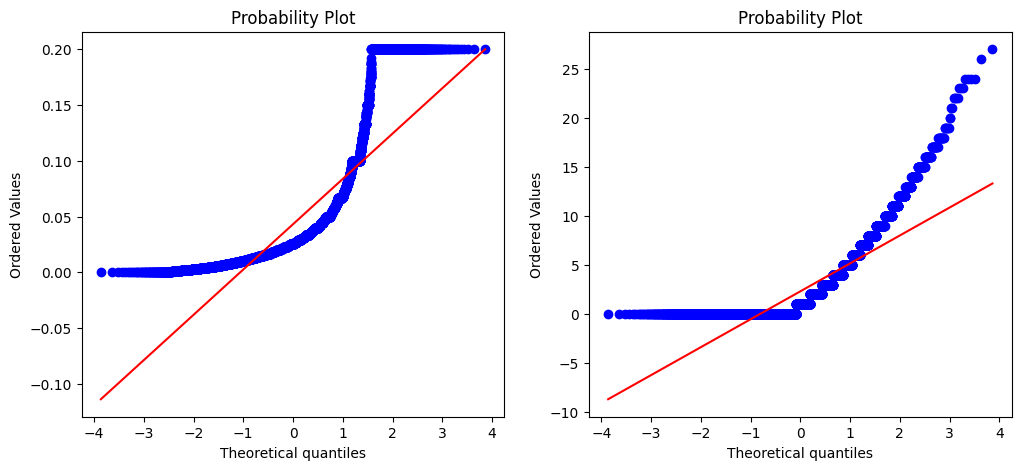

In [17]:
from scipy import stats
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
stats.probplot(df['ExitRates'], dist="norm", plot=plt)

plt.subplot(1, 2, 2)
stats.probplot(df['Administrative'], dist="norm", plot=plt)

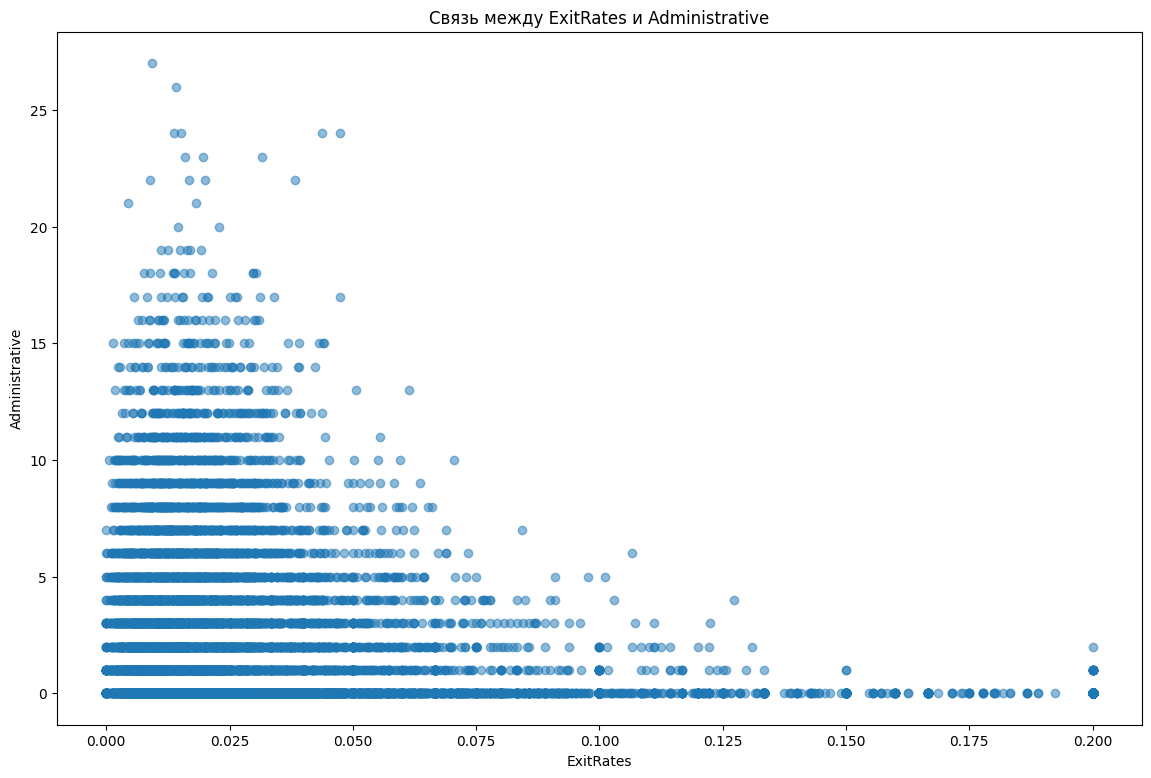

In [13]:
fig, ax = plt.subplots(figsize=(14,9))
color_graph = ax.scatter(df['ExitRates'],
                         df['Administrative'],
                         alpha=0.5)
ax.set_xlabel('ExitRates')
ax.set_ylabel('Administrative')

ax.set_title('Связь между ExitRates и Administrative')

plt.show()

In [14]:
from scipy.stats import spearmanr

spearmanr(df['Administrative'], df['ExitRates'])

SignificanceResult(statistic=np.float64(-0.4343889333418239), pvalue=np.float64(0.0))

Получился довольно интересный результат: между признаками есть умеренная отрицательная корреляция. То есть гипотезу H0 мы можем отклонить (т.к. p-value < 0.05) и сделать вывод, что количество посещенных административных страниц обратным образом слияет на агрегированную вероятность ухода с каждой страницы. То есть, можно предположить, что вероятность ухода с административных страниц низкая.

Также проверим с помощью статистического теста, влияет ли количество административных страниц, посещенных пользователем за время сессии, и продолжительность их просмотра на Revenue. Так как данные распределены не нормально, воспользуемся тестом Манна-Уитни.

In [31]:
from scipy.stats import mannwhitneyu

In [32]:
buyers = df[df['Revenue'] == True]['Administrative']
not_buyers = df[df['Revenue'] == False]['Administrative']

stat, p_value = mannwhitneyu(buyers, not_buyers)

print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 12464040.5, p-значение: 1.3119317092531031e-77


In [33]:
buyers = df[df['Revenue'] == True]['Administrative_Duration']
not_buyers = df[df['Revenue'] == False]['Administrative_Duration']

stat, p_value = mannwhitneyu(buyers, not_buyers)

print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 12398061.0, p-значение: 4.672260904769866e-74


В обоих случаях у нас p_value << 0.05, значит, отличия статистически значимы, значит, метрики оказывают влияние на конверсию посетителей в покупателей.

Итого, можно сделать вывод, что есть смысл уделять внимание улучшению административных страниц, так как они влияют на покупку и их посещение снижает вероятность ухода пользователя, что также положительно влияет на покупку.

Далее расмотрим аналогично информационные страницы.

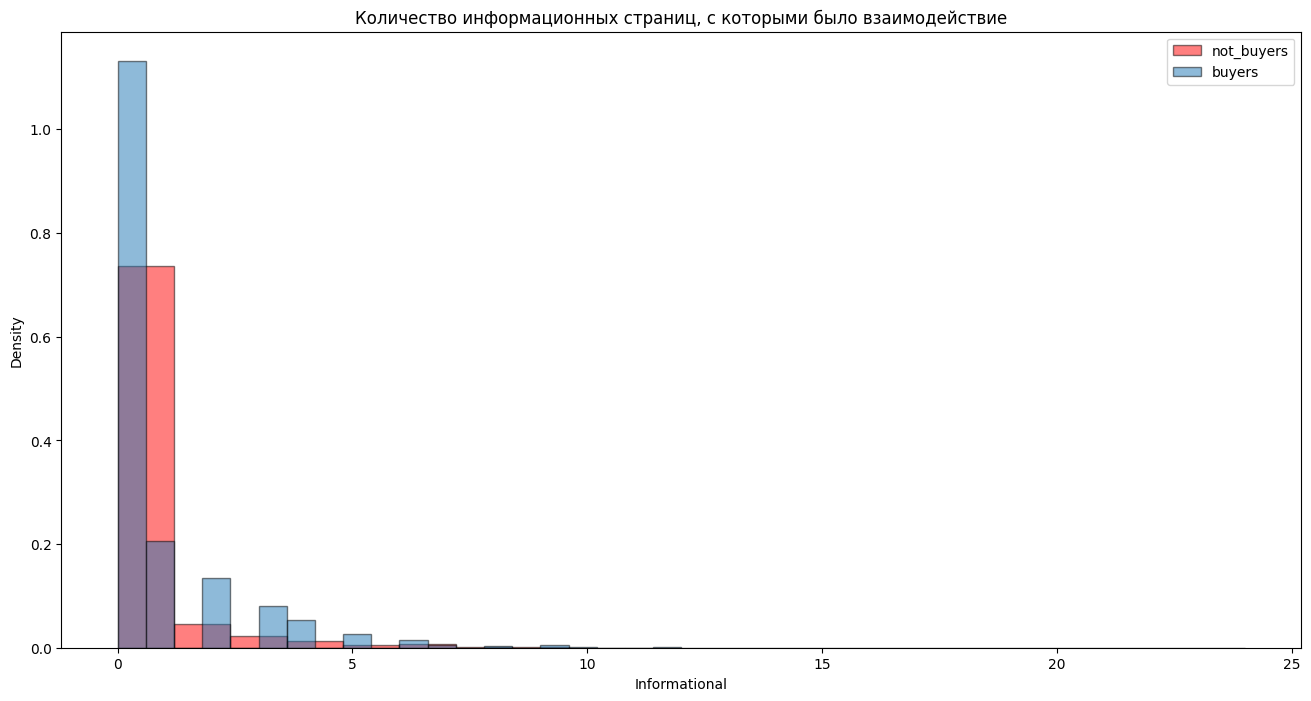

In [25]:
figsize(16, 8)

plt.hist(not_buyers['Informational'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', color='red', label='not_buyers')
plt.hist(buyers['Informational'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', label='buyers')

plt.xlabel('Informational')
plt.ylabel('Density')
plt.title('Количество информационных страниц, с которыми было взаимодействие')
plt.legend()

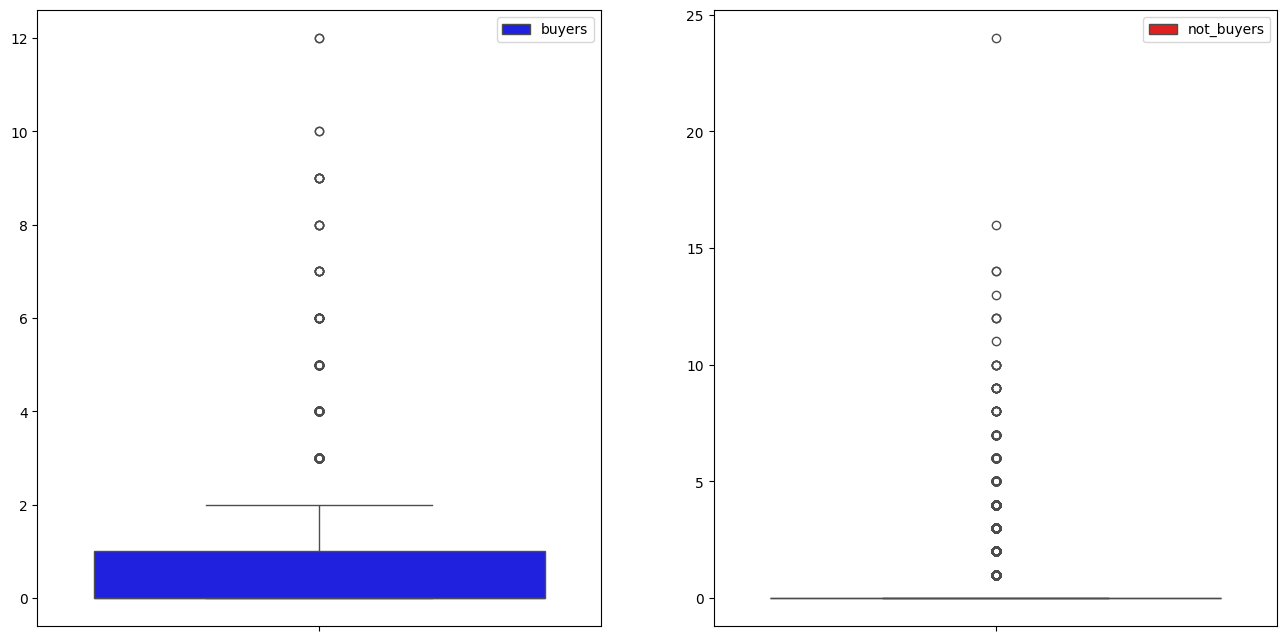

In [26]:
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
sns.boxplot(data=buyers['Informational'].values, color = 'blue', label='buyers')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=not_buyers['Informational'].values, color = 'red', label='not_buyers')
plt.legend()

In [48]:
print("Среднее у покупателей:", df[df['Revenue']==True]['Informational'].mean())
print("Среднее у не покупателей:", df[df['Revenue']==False]['Informational'].mean())

Среднее у покупателей: 0.7861635220125787
Среднее у не покупателей: 0.45183266167722125


Видим, что пользователи, которые совершают покупку, больше взаимодействуют с информационными страницами. Вероятно, изучают условия доставки, политику магазина и проч. Но все же значения довольно низкие.

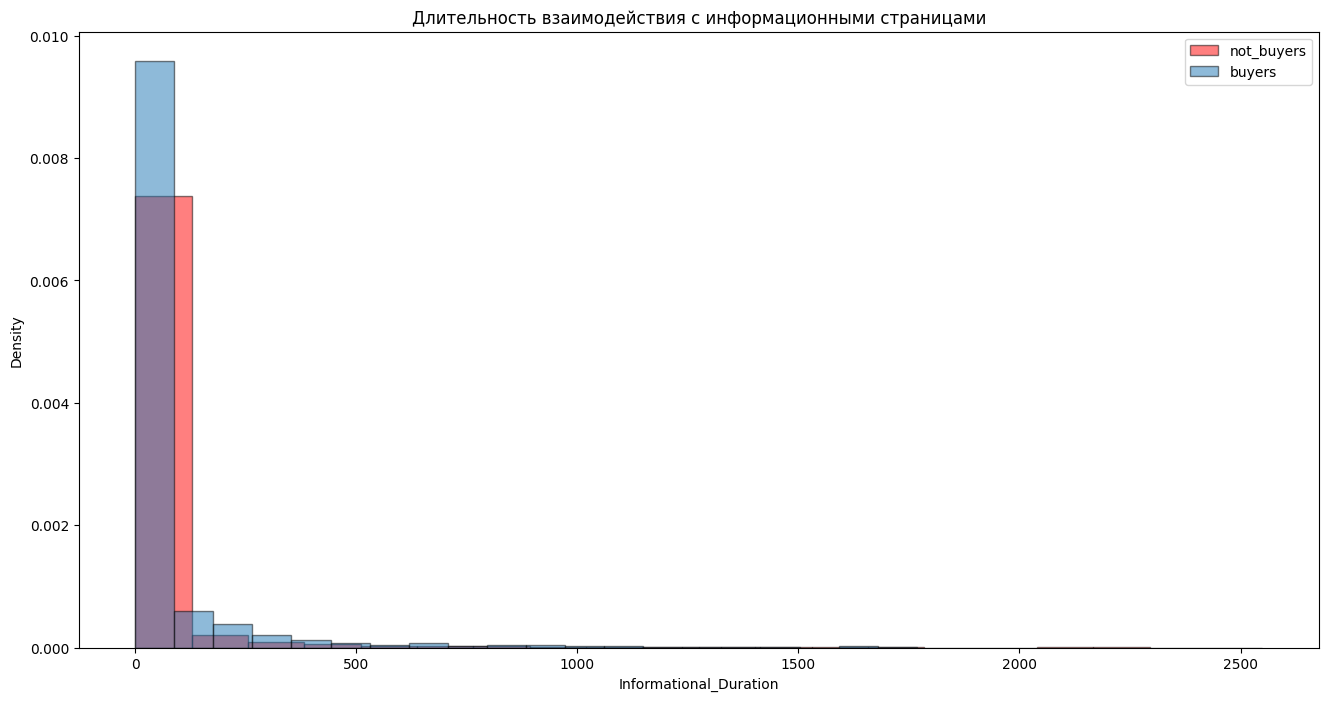

In [27]:
figsize(16, 8)

plt.hist(not_buyers['Informational_Duration'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', color='red', label='not_buyers')
plt.hist(buyers['Informational_Duration'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', label='buyers')

plt.xlabel('Informational_Duration')
plt.ylabel('Density')
plt.title('Длительность взаимодействия с информационными страницами')
plt.legend()

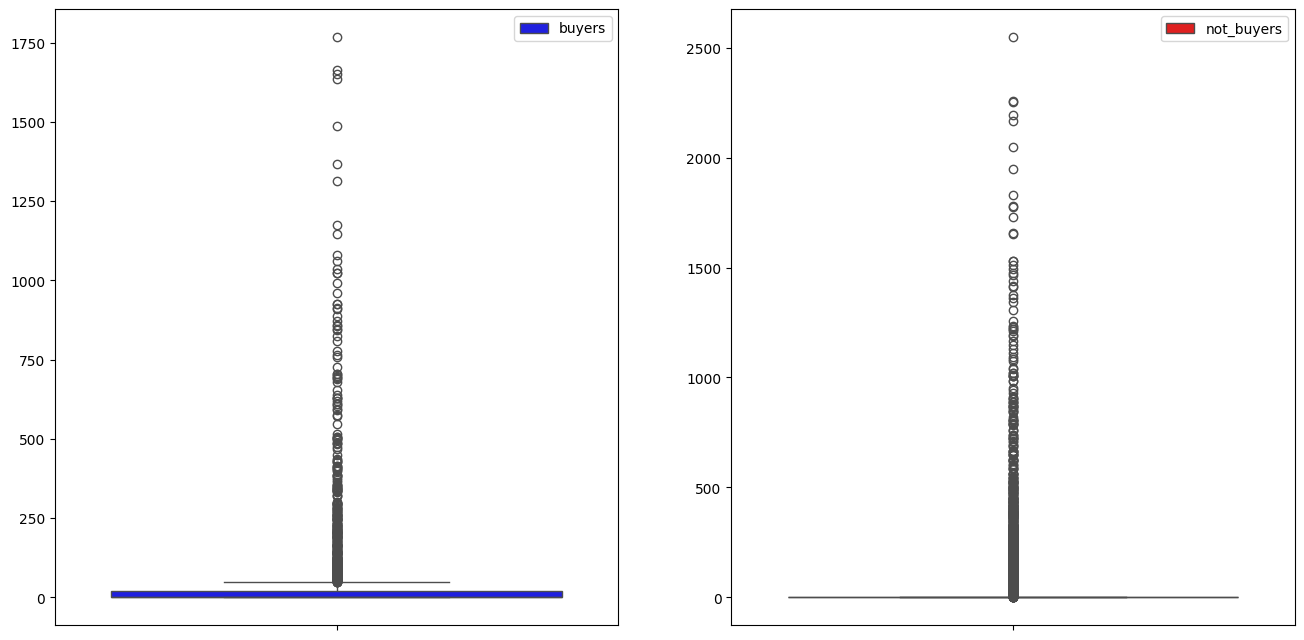

In [28]:
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
sns.boxplot(data=buyers['Informational_Duration'].values, color = 'blue', label='buyers')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=not_buyers['Informational_Duration'].values, color = 'red', label='not_buyers')
plt.legend()

Аналогично административным страницам пользователи, совершившие покупку, дольше в среднем изучают информационные страницы, но также самые большие выбросы у тех кто покупку не совершил (вероятно, долго не могли разобраться). Но также как и с количеством страниц значения низкие.

В целом визуально влияние на конверсию слабее, чем у административных страниц, но проведем аналогичное исследование.

<Axes: xlabel='VisitorType', ylabel='Informational_Duration'>

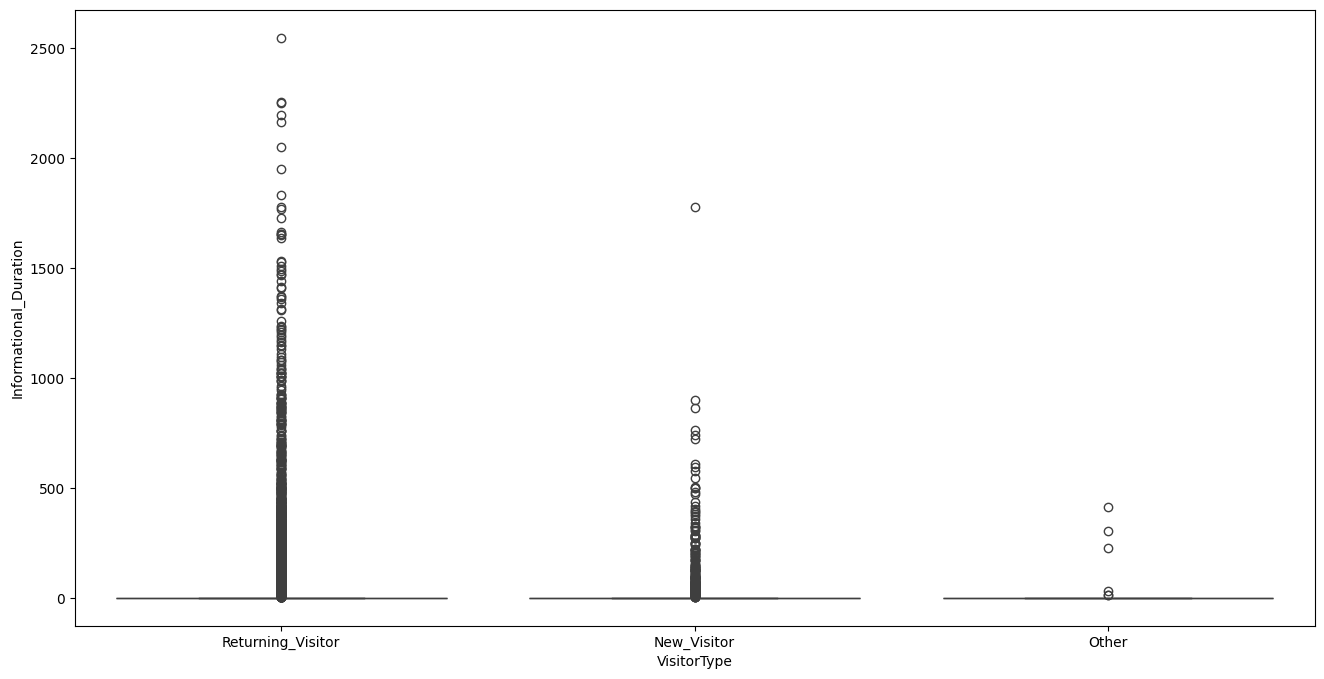

In [36]:
sns.boxplot(data=df, x='VisitorType', y='Informational_Duration')

<Axes: xlabel='VisitorType', ylabel='Informational_Duration'>

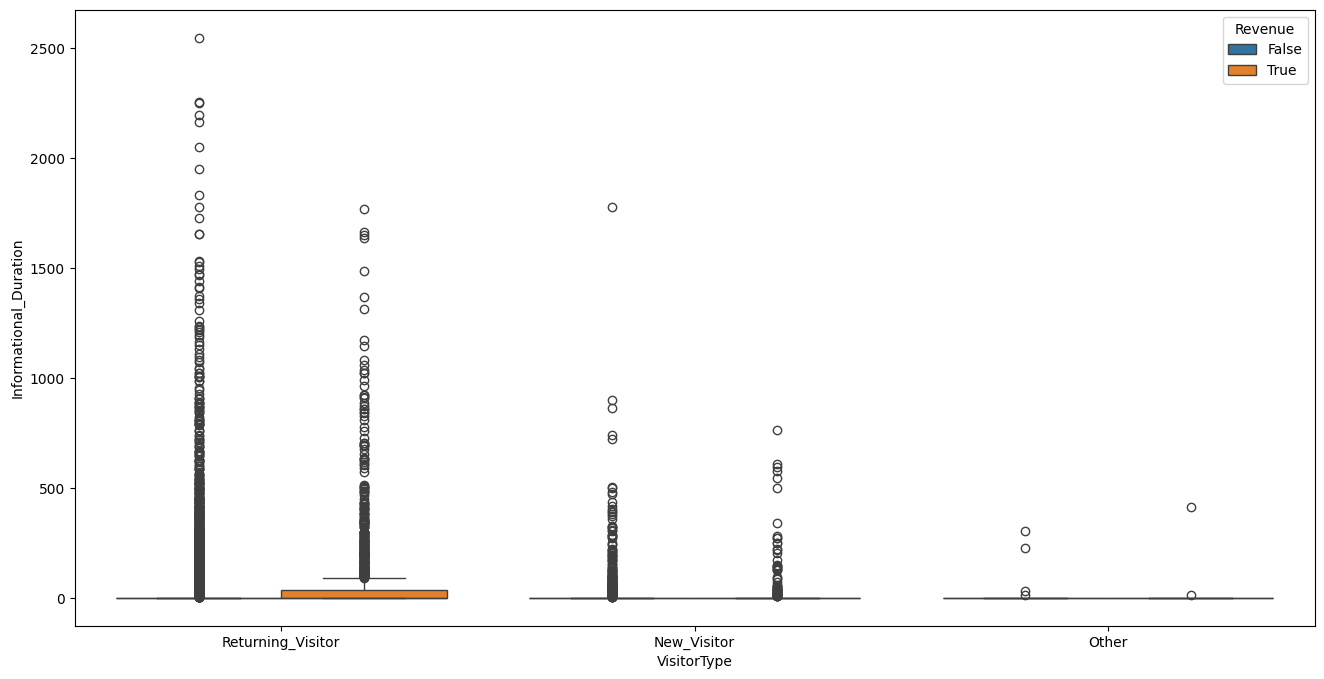

In [ ]:
sns.boxplot(data=df, x='VisitorType', y='Informational_Duration', hue='Revenue')

H0: средние значения Informational_Duration одинаковы для всех типов посетителей.

H1: хотя бы у одной группы среднее значение статистически значимо отличается.

In [39]:
from scipy.stats import ttest_ind

ttest_ind(df[df['VisitorType']=='Returning_Visitor']['Informational_Duration'], df[df['VisitorType']=='New_Visitor']['Informational_Duration'], equal_var=False)

TtestResult(statistic=np.float64(7.011703162273821), pvalue=np.float64(2.8087488295211203e-12), df=np.float64(3529.7356322530854))

In [40]:
print("Среднее у новых пользователей:", df[df['VisitorType']=='New_Visitor']['Informational_Duration'].mean())
print("Среднее у старых пользователей:", df[df['VisitorType']=='Returning_Visitor']['Informational_Duration'].mean())

Среднее у новых пользователей: 19.237472452048408
Среднее у старых пользователей: 37.101992365496635


Статистический тест показал, что есть значимое отличие во времени взаимодействия с информационными страницами у вернувшихся пользователей и новых. По среднем видно, что у вернувшихся оно сильно выше. Интересно, влияет ли это на их решение о покупке. Так как на графике плохо видно, посмотрим на значениях.

In [43]:
print("Среднее у новых пользователей совершивших покупку:", df[(df['VisitorType']=='New_Visitor')&(df['Revenue']==True)]['Informational_Duration'].mean())
print("Среднее у новых пользователей не совершивших покупку:", df[(df['VisitorType']=='New_Visitor')&(df['Revenue']==False)]['Informational_Duration'].mean())

print("Среднее у старых пользователей совершивших покупку:", df[(df['VisitorType']=='Returning_Visitor')&(df['Revenue']==True)]['Informational_Duration'].mean())
print("Среднее у старых пользователей не совершивших покупку:", df[(df['VisitorType']=='Returning_Visitor')&(df['Revenue']==False)]['Informational_Duration'].mean())


Среднее у новых пользователей совершивших покупку: 19.761532385616114
Среднее у новых пользователей не совершивших покупку: 19.063609801132074
Среднее у старых пользователей совершивших покупку: 68.81818733554898
Среднее у старых пользователей не совершивших покупку: 31.967887464497082


Видим, что у новых пользователей среднее время изучения информационных страниц примерно одинаковое - значит, оно особо не влияет на покупку, новые пользователи одинаковое кол-во времени изучают информацию.

А вот у вернувшихся пользователей, совершивших покупку, среднее время нахождения на информационных страницах значительно выше, чем у вернувшихся пользователей, не совершивших покупку. Можно предположить, что вернувшиеся пользователи уже знают, куда смотреть на информационных страницах, и изучают их с целью получить информацию о заказе.

Можно сделать вывод, что вернувшиеся пользователи более вовлечены в изучение информационных страниц, возможно, стоит собирать информацию для новичков в отдельную карточку, а для повышения лояльности вернувшихся пользователей улучшать информационные страницы, добавлять туда какой-то контент.

Посмотрим в целом влияние на покупку с помощью любимого Манна-Уитни, так как судя по графикам данные не распределены нормально.

In [44]:
buyers = df[df['Revenue'] == True]['Informational_Duration']
not_buyers = df[df['Revenue'] == False]['Informational_Duration']

stat, p_value = mannwhitneyu(buyers, not_buyers)

print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 11173527.0, p-значение: 1.4090385051061036e-35


In [45]:
buyers = df[df['Revenue'] == True]['Informational']
not_buyers = df[df['Revenue'] == False]['Informational']

stat, p_value = mannwhitneyu(buyers, not_buyers)

print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 11236434.0, p-значение: 1.2027813960741893e-36


p-value в обоих случаях <<0.05, значит, вовлеченность в изучение информационных страниц статистически значимо влияет на покупку. 